# 7: Statistics

In [ ]:
import alpaca
from alpaca.statistics import get_chi2, ChiSquaredList
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'text.usetex': True, 'font.family': 'serif', 'font.serif': 'Computer Modern Roman'})

In this example we consider a $20\times20$ grid in parameter space with $m_a \in [0.01, 4]\,\mathrm{GeV}$, $f_a \in [10^3,10^8]\,\mathrm{GeV}$ and $c_t(\Lambda=4\pi f_a) =1$. For a more realistic application the grid should be larger.

In [2]:
#Create grid of ma, fa and couplings
ma = np.logspace(-2, np.log10(4), 20)
fa = np.logspace(3, 8, 20)
x_ma, y_fa = np.meshgrid(ma, fa)
couplings = [alpaca.ALPcouplings({'cuR': np.diag([0,0,1])},
    4*np.pi*f, 'derivative_above').match_run(4, 'VA_below') for f in fa]
x_ma, y_couplings = np.meshgrid(ma, couplings)


One possible way to define the $\chi^2$ analysis is by specifying the processes:

In [3]:
transitions_BKll = [
    'B+ -> K+ mu mu',
    'B+ -> K+ e e',
    'B0 -> K*0 mu mu',
    'B0 -> K*0 e e'
]

chi2_BKll = get_chi2(
    transitions_BKll,
    x_ma,
    y_couplings,
    y_fa,
    integrator='no_rge'   # The running below 4 GeV is negligible
)

The $\chi^2$ of each transition can be obtained by indexing the `ChiSquaredList` object

In [4]:
chi2_BKll

|Index|Sector|
| :-: | :- |
|0|$$B^+ \to K^+ \mu \mu$$|
|1|$$B^+ \to K^+ e e$$|
|2|$$B^0 \to K^{*0} \mu \mu$$|
|3|$$B^0 \to K^{*0} e e$$|

In [5]:
chi2_BKll[0]

## B+ -> K+ mu mu

**LaTeX**: $B^+ \to K^+ \mu \mu$

**Description**: Observable B+ -> K+ mu mu

**Observables**:
- $B^+ \to K^+ \mu \mu$

and the $\chi^2$ of several observables can be combined together,

In [6]:
#Select only B -> K mu mu observables
chi2_BKmumu = ChiSquaredList([chi2_BKll[0], chi2_BKll[2]])

#Obtain combined chi2
chi2_comb = chi2_BKmumu.combine(
    name = 'B->Kmumu',
    tex = r'$B \to K \mu^+ \mu^-$',
    description = 'Combined chi2 to B -> K mu mu observables'
)

In [7]:
chi2_comb

## B->Kmumu

**LaTeX**: $B \to K \mu^+ \mu^-$

**Description**: Combined chi2 to B -> K mu mu observables

**Observables**:
- $B^+ \to K^+ \mu \mu$
- $B^0 \to K^{*0} \mu \mu$

Alternatively, the user can also specify sectors, or a mix of processes and sectors

In [8]:
transitions_inv = [
    alpaca.sectors.default_sectors['Kpiinv'],
    alpaca.sectors.default_sectors['BKinv']
]

chi2_inv = get_chi2(
    transitions_inv,
    x_ma,
    y_couplings,
    y_fa,
    integrator='no_rge'   # The running below 4 GeV is negligible
)

In [9]:
chi2_inv

|Index|Sector|
| :-: | :- |
|0|$$K \to \pi + \mathrm{inv.}$$|
|1|$$B \to K^{(*)} + \mathrm{inv.}$$|

The significance of each observable or sector is obtained as

In [10]:
sigmas_Kpiinv = chi2_inv[0].significance()
sigmas_BKinv = chi2_inv[1].significance()
sigmas_inv = chi2_inv.significance()

In red we visualiaze the contour plots for the significance of $K\to\pi a$, in blue for $B\to K a$, and in purple their combination

Text(0, 0.5, '$1/f_a$ [GeV$^{-1}$]')

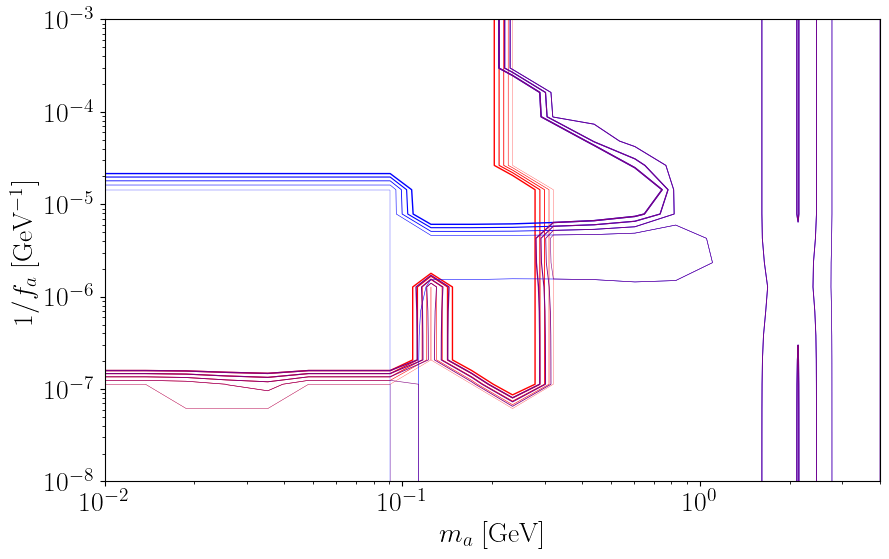

In [11]:
plt.figure(figsize=(10, 6))
plt.contour(x_ma, 1/y_fa, sigmas_Kpiinv, levels=list(np.arange(0, 5, 1.0)), colors='r', linewidths=[0.2, 0.4, 0.6, 0.8, 1.0], linestyles='solid')
plt.contour(x_ma, 1/y_fa, sigmas_BKinv, levels=list(np.arange(0, 5, 1.0)), colors='b', linewidths=[0.2, 0.4, 0.6, 0.8, 1.0], linestyles='solid')
plt.contour(x_ma, 1/y_fa, sigmas_inv, levels=list(np.arange(0, 5, 1.0)), colors='purple', linewidths=[0.2, 0.4, 0.6, 0.8, 1.0], linestyles='solid')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')

The contours of constant significance can be extracted with `contour`, and saved with `contour_to_csv`,

Text(0, 0.5, '$1/f_a$ [GeV$^{-1}$]')

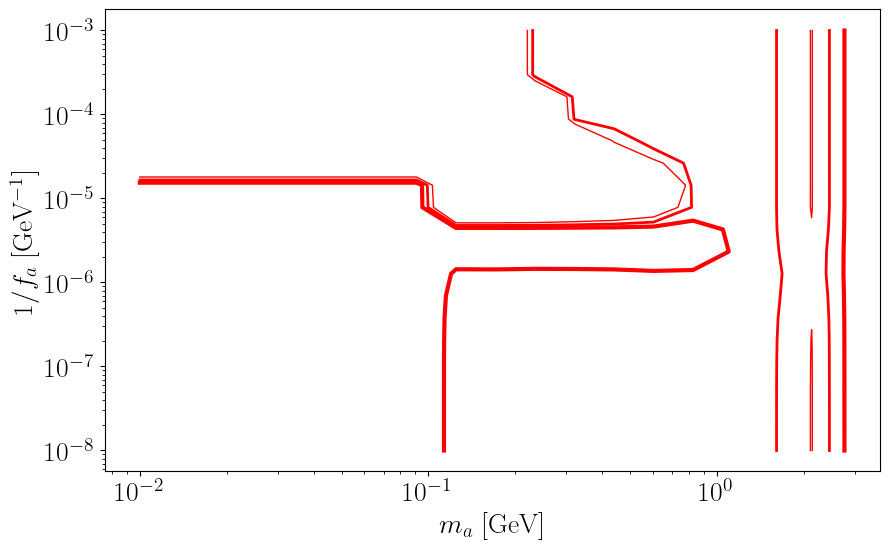

In [22]:
fig = plt.figure(figsize=(10, 6))
for sigma in [1, 2, 3]:
    x_contour, y_contour = chi2_inv[1].contour(ma, fa, sigma)
    plt.loglog(x_contour, 1/y_contour, color='r', lw = 4-sigma)
    chi2_inv[1].contour_to_csv(ma, fa, f'07_results/BKnunu_{sigma}sigma.csv',
                            sigma, 'ma', 'fa')
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')

We can see which observables and measurements are included in each `ChiSquared` and `ChiSquaredList` object:

In [13]:
chi2_inv.get_observables()

['KL -> alp pion0',
 'B+ -> K+ alp',
 'B+ -> K*+ alp',
 'B0 -> K0 alp',
 'K+ -> alp pion+']

In [14]:
chi2_inv.get_measurements()

[('B+ -> K*+ alp', 'BaBar'),
 ('K+ -> alp pion+', 'NA62(2022)'),
 ('K+ -> alp pion+', 'E949'),
 ('KL -> alp pion0', 'KOTO'),
 ('K+ -> alp pion+', 'NA62'),
 ('B0 -> K0 alp', 'Belle'),
 ('B+ -> K+ alp', 'BaBar'),
 ('B+ -> K+ alp', 'Belle II')]

We can obtain the separated `ChiSquared` objects for each observable or measurement with the respective `split_observable` or `split_measurement`

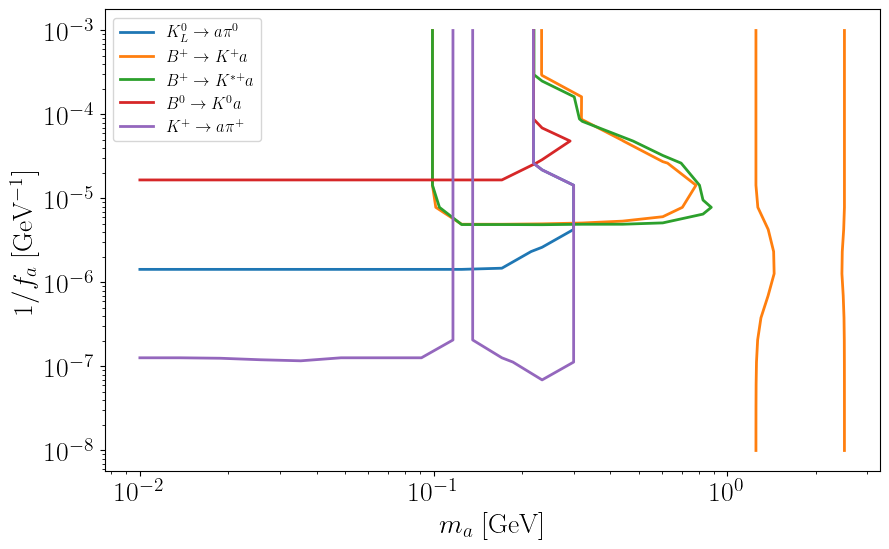

In [23]:
fig = plt.figure(figsize=(10, 6))
for chi2_obs in chi2_inv.split_observables():
    x_contour, y_contour = chi2_obs.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_obs.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

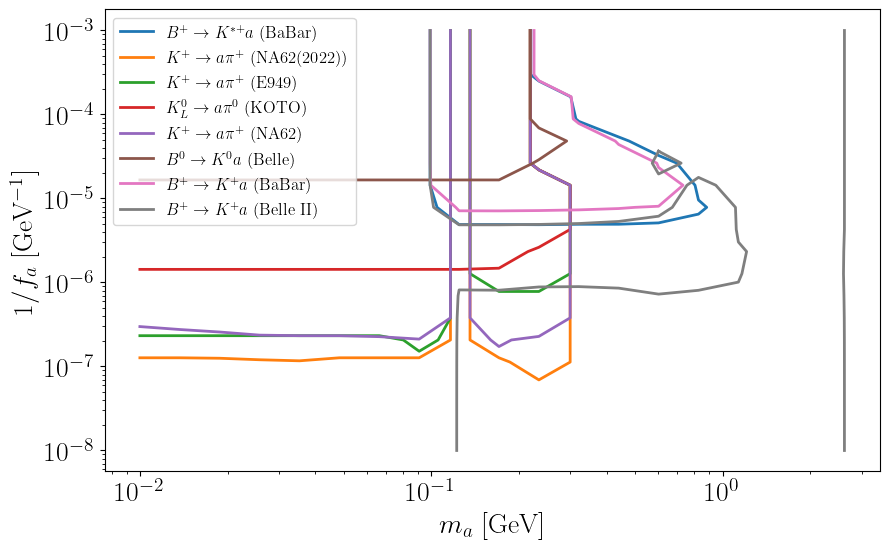

In [24]:
fig = plt.figure(figsize=(10, 6))
for chi2_meas in chi2_inv.split_measurements():
    x_contour, y_contour = chi2_meas.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_meas.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

The methods `exclude_observables` and `exclude_measurements` produces a new `ChiSquared` or `ChiSquaredList` object removing the specified observables or measurements:

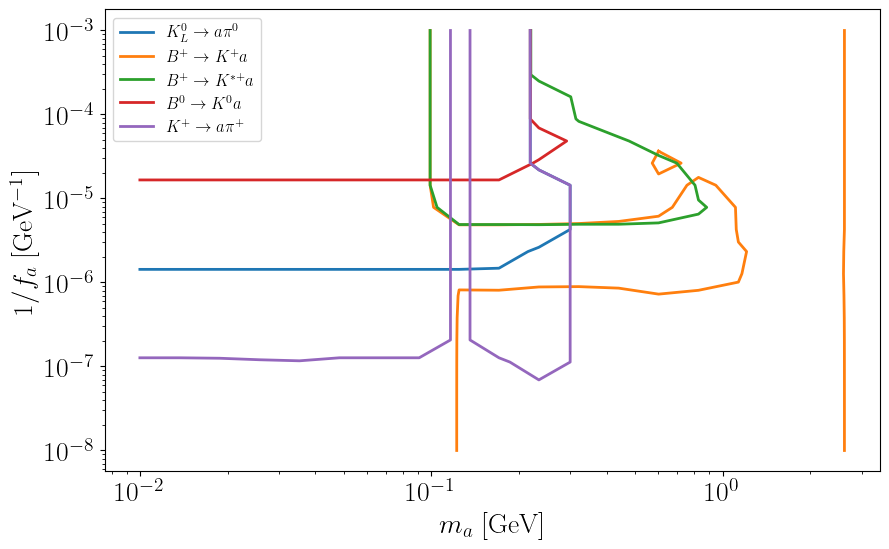

In [ ]:
# We remove the BaBar measurement of B+ -> K+ a. There is still a measurement from Belle II.

fig = plt.figure(figsize=(10, 6))
for chi2_obs in chi2_inv.exclude_measurements([('B+ -> K+ a', 'BaBar')]).split_observables():
    x_contour, y_contour = chi2_obs.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_obs.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

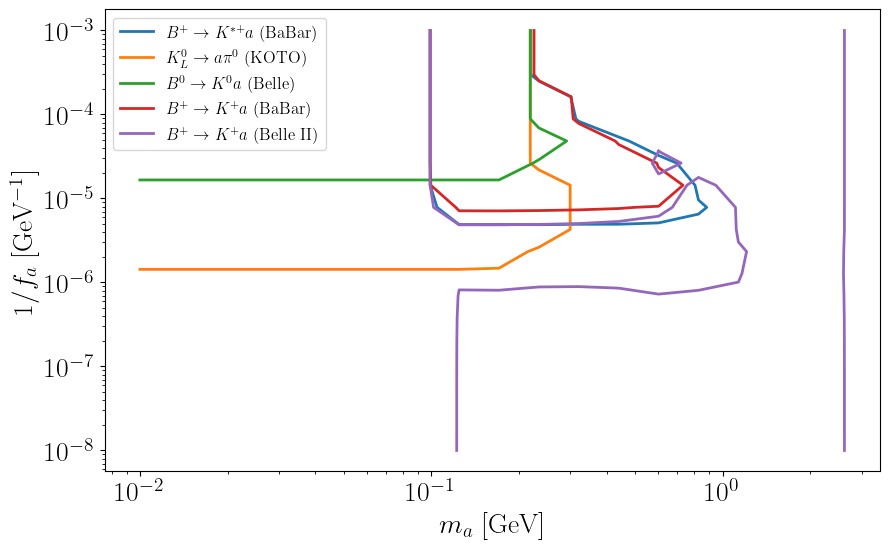

In [ ]:
# We remove all measurements of K+ -> pi+ a

fig = plt.figure(figsize=(10, 6))
for chi2_meas in chi2_inv.split_measurements().exclude_observables(['K+ -> pi+ a']):
    x_contour, y_contour = chi2_meas.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_meas.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

If we only want to retain some observables or measurements, then we use `extract_observables` or `extract_measurements`:

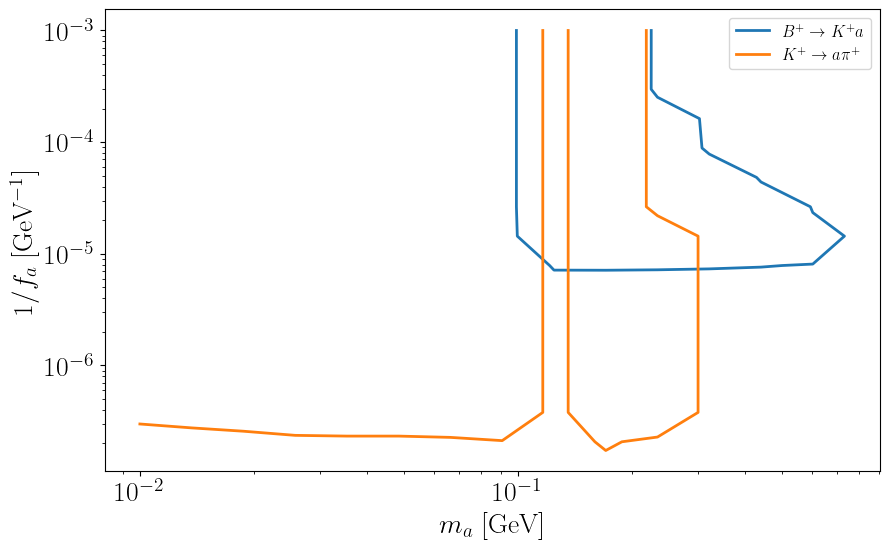

In [29]:
fig = plt.figure(figsize=(10, 6))
for chi2_obs in chi2_inv.extract_measurements([('B+ -> K+ a', 'BaBar'), ('K+ -> pi+ a', 'NA62')]).split_observables():
    x_contour, y_contour = chi2_obs.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_obs.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

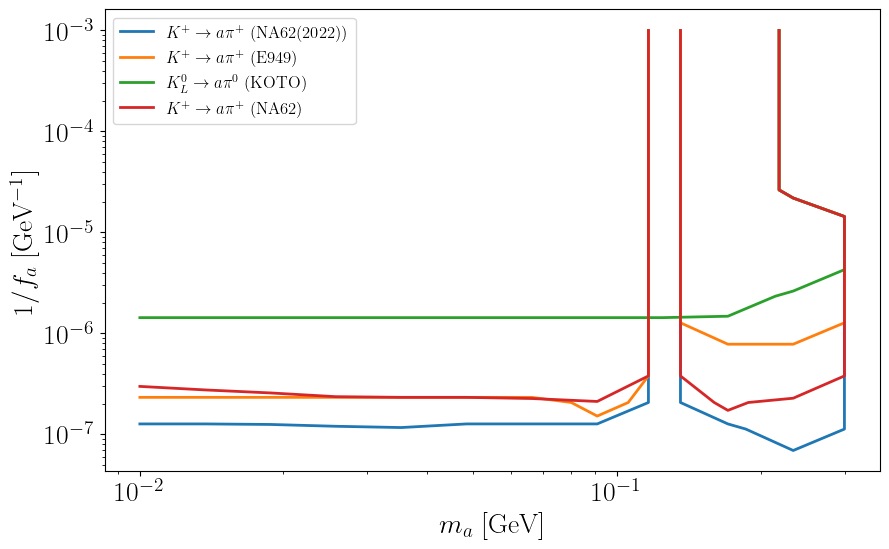

In [30]:
fig = plt.figure(figsize=(10, 6))
for chi2_meas in chi2_inv.split_measurements().extract_observables(['K+ -> pi+ a', 'KL -> pi0 a']):
    x_contour, y_contour = chi2_meas.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_meas.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

It is also possible to remove the measurements or observables that do not contribute to the overall significance,

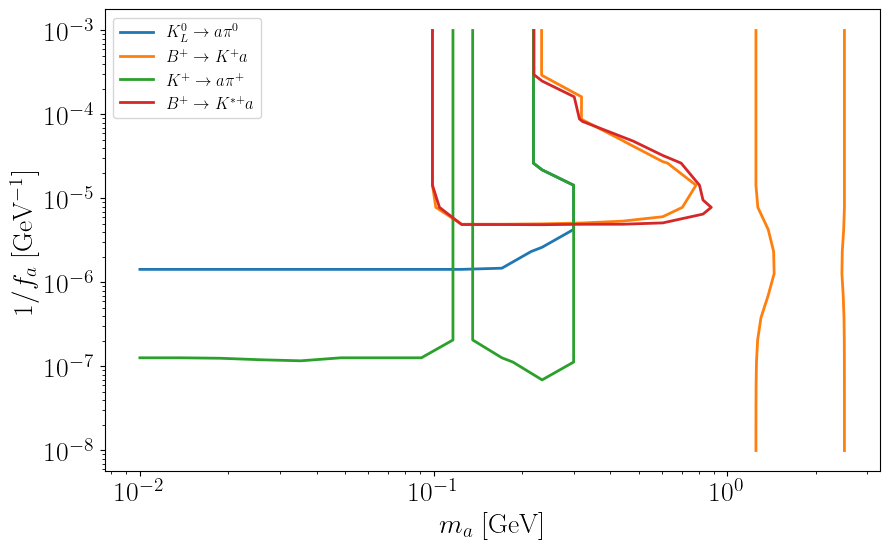

In [31]:
fig = plt.figure(figsize=(10, 6))
for chi2_obs in chi2_inv.split_observables().constraining_observables():
    x_contour, y_contour = chi2_obs.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_obs.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

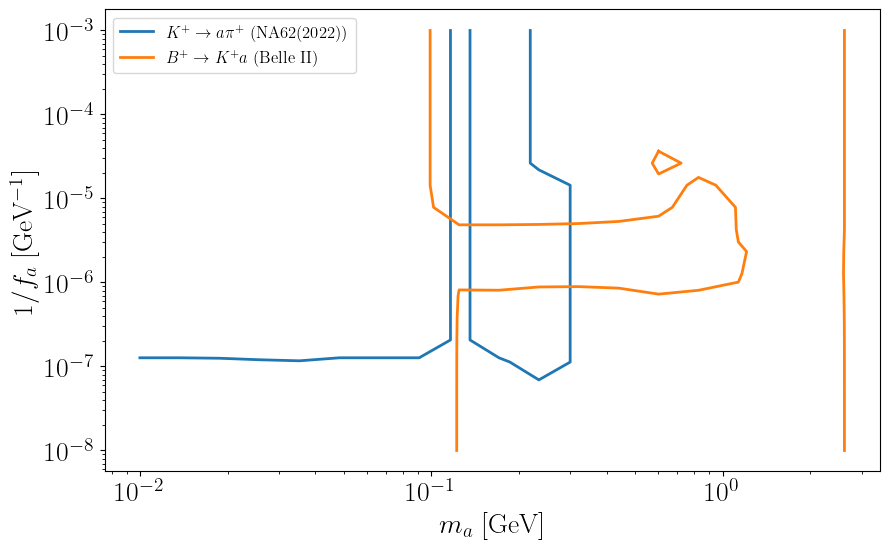

In [32]:
fig = plt.figure(figsize=(10, 6))
for chi2_meas in chi2_inv.split_measurements().constraining_measurements():
    x_contour, y_contour = chi2_meas.contour(ma, fa, 2.0)
    plt.loglog(x_contour, 1/y_contour, label=chi2_meas.sector.tex, lw=2)
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'$1/f_a$ [GeV$^{-1}$]')
plt.legend(fontsize=12)

The `silicing` method allows to restrict the analysis to a smaller region of the parameter space:

In [35]:
# we select the first 15 values of ma, and the third value of fa
x_ma_slice = x_ma[2,:15]
fa_slice = y_fa[2,:15]
chi2_slice = chi2_inv.slicing(2, slice(0,15))
chi2BKa_slice = chi2_inv[0].slicing(2, slice(0,15))
# or equivalently
chi2BKa_slice = chi2_inv[0][2,:15]

In [36]:
x_ma_slice

array([0.01      , 0.01370726, 0.01878889, 0.02575441, 0.03530223,
       0.04838967, 0.06632896, 0.0909188 , 0.12462472, 0.1708263 ,
       0.23415598, 0.3209636 , 0.43995303, 0.60305488, 0.82662277])

In [37]:
fa_slice

array([3359.81828628, 3359.81828628, 3359.81828628, 3359.81828628,
       3359.81828628, 3359.81828628, 3359.81828628, 3359.81828628,
       3359.81828628, 3359.81828628, 3359.81828628, 3359.81828628,
       3359.81828628, 3359.81828628, 3359.81828628])

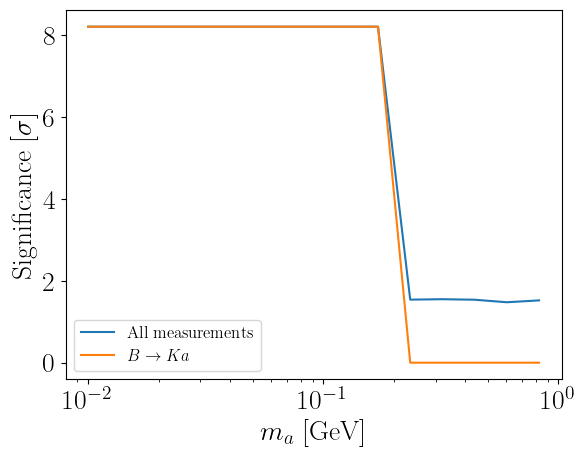

In [47]:
plt.semilogx(x_ma_slice, chi2_slice.significance(), label='All measurements')
plt.semilogx(x_ma_slice, chi2BKa_slice.significance(), label=r'$B \to K a$')
plt.xlabel(r'$m_a$ [GeV]')
plt.ylabel(r'Significance [$\sigma$]')
plt.legend(fontsize=12)